## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [51]:
bank_marketing = fetch_ucirepo(id=222)
X_raw = bank_marketing.data.features
y_raw = bank_marketing.data.targets

df_raw = pd.concat([X_raw, y_raw], axis=1)
df = df_raw.copy()

print("Initial shape:", df.shape)
display(df.head())

Initial shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [52]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

Numeric cols: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Categorical cols: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [53]:
print("Missing values per column:")
print(df.isnull().sum())

for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    print(f"{col}: {unknown_count} 'unknown' values")

Missing values per column:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64
job: 0 'unknown' values
marital: 0 'unknown' values
education: 0 'unknown' values
default: 0 'unknown' values
housing: 0 'unknown' values
loan: 0 'unknown' values
contact: 0 'unknown' values
month: 0 'unknown' values
poutcome: 0 'unknown' values
y: 0 'unknown' values


,min,max,mean,std,skewness
age,18.0,95.0,40.936210,10.618762,0.684818
balance,-8019.0,102127.0,1362.272058,3044.765829,8.360308
day_of_week,1.0,31.0,15.806419,8.322476,0.093079
duration,0.0,4918.0,258.163080,257.527812,3.144318
campaign,1.0,63.0,2.763841,3.098021,4.898650
pdays,-1.0,871.0,40.197828,100.128746,2.615715
previous,0.0,275.0,0.580323,2.303441,41.846454


Missing values per column:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


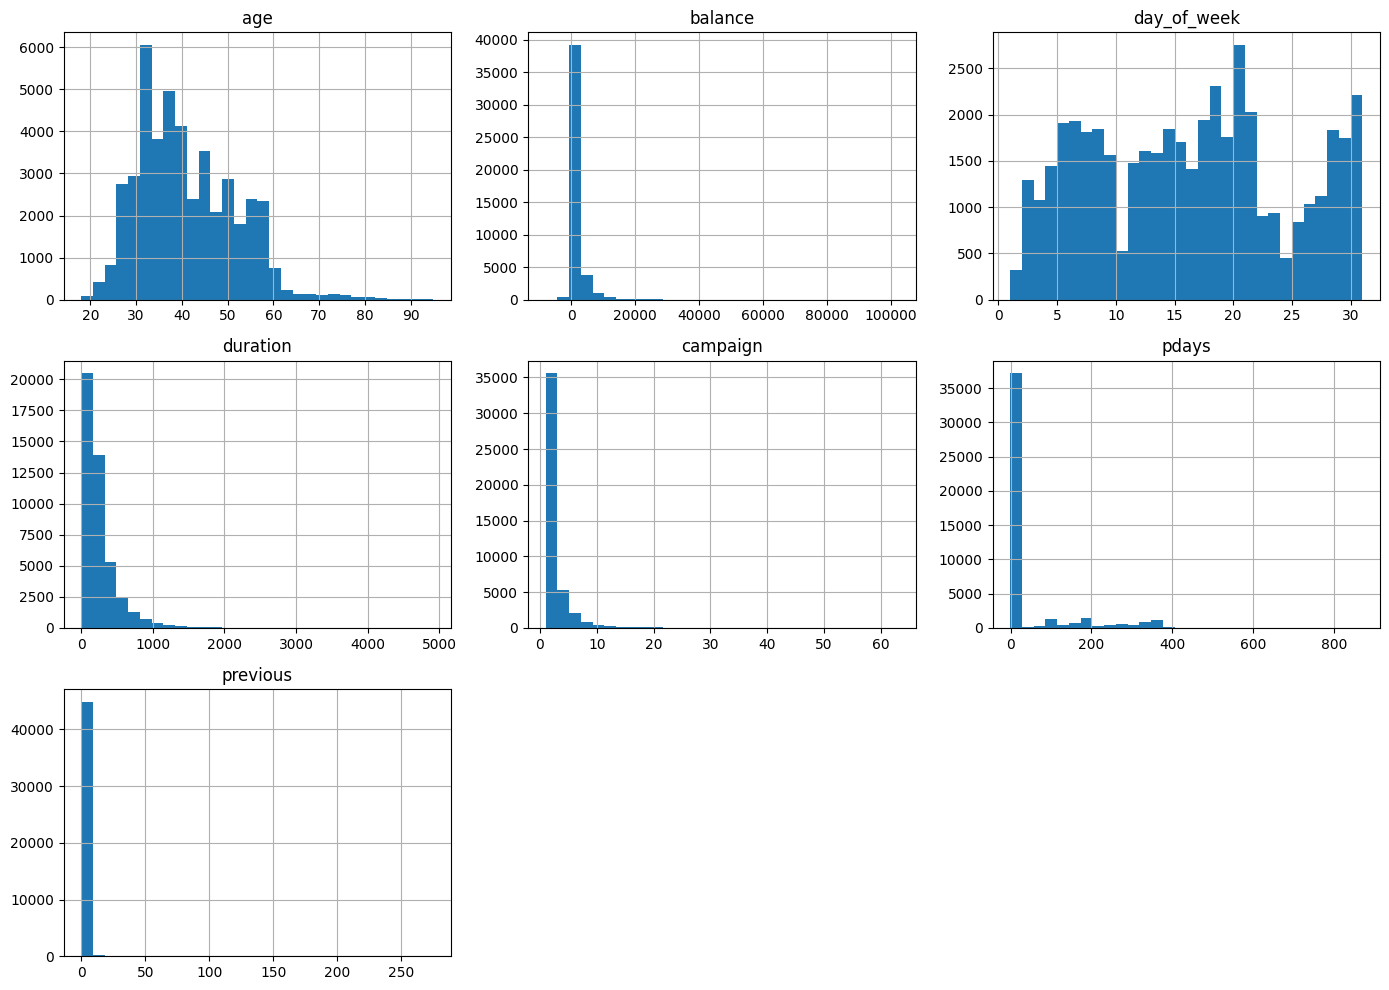

In [59]:
stats = df[numeric_cols].describe().T
stats["skewness"] = df[numeric_cols].skew(numeric_only=True)
display(stats[["min","max","mean","std","skewness"]])

print("Missing values per column:")
print(df.isnull().sum())

df[numeric_cols].hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

In [62]:
for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    print(f"{col}: {unknown_count} 'unknown' values")

job: 0 'unknown' values
marital: 0 'unknown' values
education: 0 'unknown' values
default: 0 'unknown' values
housing: 0 'unknown' values
loan: 0 'unknown' values
contact: 0 'unknown' values
month: 0 'unknown' values
poutcome: 0 'unknown' values
y: 0 'unknown' values


In [61]:
for col in categorical_cols:
    print("\n", col)
    display(df[col].value_counts(dropna=False))


 job


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
NaN               288
Name: count, dtype: int64


 marital


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


 education


...

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


 poutcome


poutcome
NaN        36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


 y


y
no     39922
yes     5289
Name: count, dtype: int64

In [56]:
print(df[numeric_cols].corr().round(2))

# Only correlation is between pdays and previous which makes sense, clients contacted more recently were also contacted more times before

              age  balance  day_of_week  duration  campaign  pdays  previous
age          1.00     0.10        -0.01     -0.00      0.00  -0.02      0.00
balance      0.10     1.00         0.00      0.02     -0.01   0.00      0.02
day_of_week -0.01     0.00         1.00     -0.03      0.16  -0.09     -0.05
duration    -0.00     0.02        -0.03      1.00     -0.08  -0.00      0.00
campaign     0.00    -0.01         0.16     -0.08      1.00  -0.09     -0.03
pdays       -0.02     0.00        -0.09     -0.00     -0.09   1.00      0.45
previous     0.00     0.02        -0.05      0.00     -0.03   0.45      1.00


In [57]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

print(df.columns.tolist())
print(df.dtypes)

age: 487 outliers (1.1%)
balance: 4729 outliers (10.5%)
day_of_week: 0 outliers (0.0%)
duration: 3235 outliers (7.2%)
campaign: 3064 outliers (6.8%)
pdays: 8257 outliers (18.3%)
previous: 8257 outliers (18.3%)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object


### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [46]:
df.dropna(subset=['job', 'education'], inplace=True)

df['poutcome'].fillna('unknown', inplace=True)

df['contact'].fillna('unknown', inplace=True)

print(df.isnull().sum())

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64


C:\Users\kwael\AppData\Local\Temp\ipykernel_24900\1350185379.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['poutcome'].fillna('unknown', inplace=True)
C:\Users\kwael\AppData\Local\Temp\ipykernel_24900\1350185379.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [47]:
edu_order = {
    "unknown": 0, "illiterate": 1, "basic.4y": 2, "basic.6y": 3,
    "basic.9y": 4, "high.school": 5, "professional.course": 6,
    "university.degree": 7
}

df["education"] = df["education"].map(edu_order).fillna(0).astype(int)

num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for c in cat_cols:
    df[c] = df[c].fillna("unknown")

nominal_cols = ["job", "marital", "default", "housing", "loan",
                "contact", "month", "day_of_week", "poutcome"]
nominal_cols = [c for c in nominal_cols if c in df.columns]

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

X = df_encoded.drop(columns=["y"])
y = df_encoded["y"]

print("Total NaNs in X:", X.isna().sum().sum())
print("X shape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape before PCA: {X_scaled.shape}")
print(f"Shape after PCA:  {X_pca.shape}")
print(f"Components kept:  {pca.n_components_}")
print(f"Explained variance ratio sum: {pca.explained_variance_ratio_.sum():.4f}")

Total NaNs in X: 0
X shape: (43193, 68)
Shape before PCA: (43193, 68)
Shape after PCA:  (43193, 56)
Components kept:  56
Explained variance ratio sum: 0.9516


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

Cluster sizes:
{np.int32(0): np.int64(900), np.int32(1): np.int64(7717), np.int32(2): np.int64(19834), np.int32(3): np.int64(14742)}


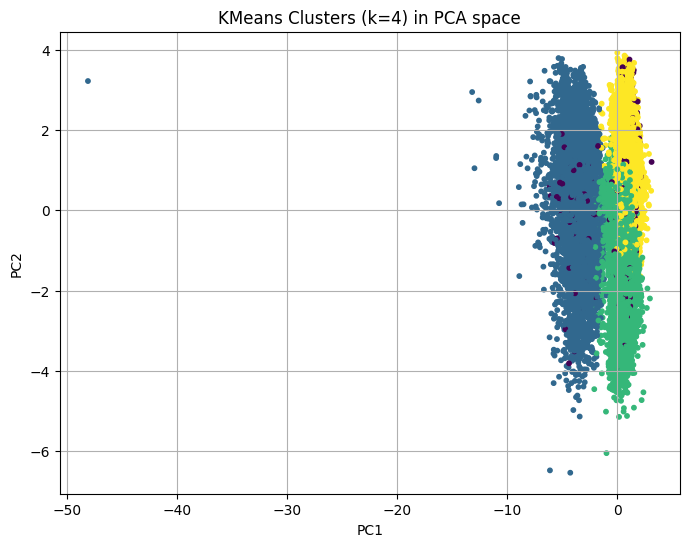

In [66]:
k = 4
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

print("Cluster sizes:")
unique, counts = np.unique(cluster_labels, return_counts=True)
print(dict(zip(unique, counts)))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={k}) in PCA space")
plt.grid(True)
plt.show()

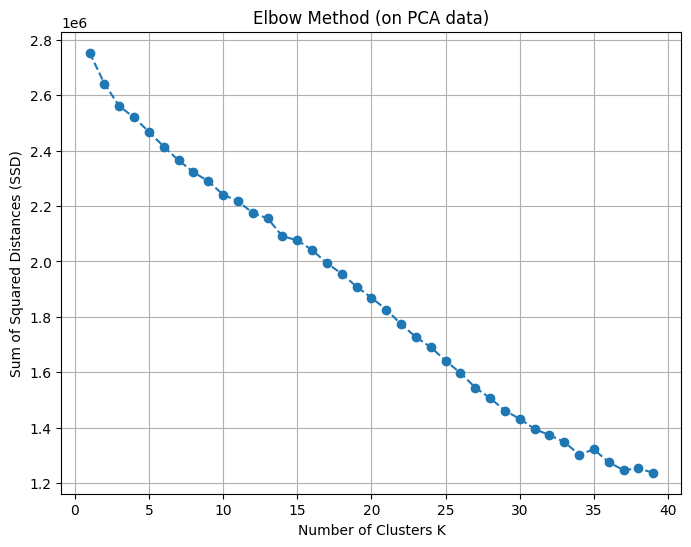

In [48]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ssd = []
K_range = range(1, 40)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_pca)   
    ssd.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K_range, ssd, 'o--')
plt.xlabel("Number of Clusters K")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method (on PCA data)")
plt.grid(True)
plt.show()

### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

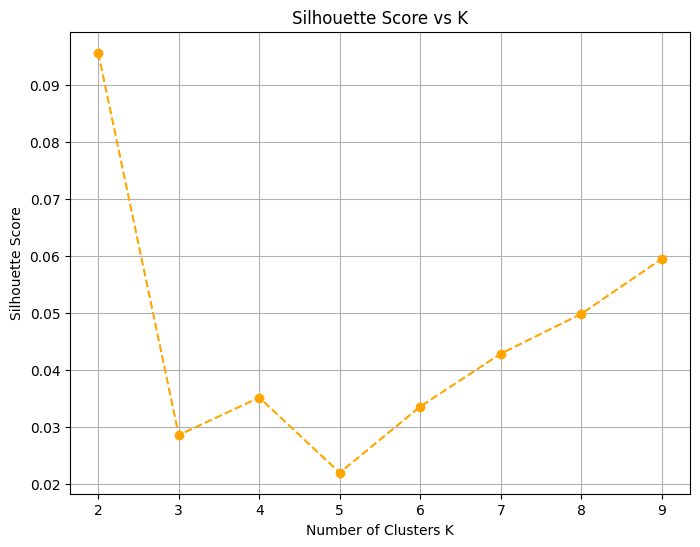

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    sil_scores.append(score)

plt.figure(figsize=(8,6))
plt.plot(range(2,10), sil_scores, 'o--', color='orange')
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()